In [1]:
!pip install torch torchvision scikit-learn matplotlib pillow


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
from PIL import Image


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [5]:
#Drive Runtime
DATA_DIR = "/content/drive/MyDrive/CDT_Dataset"  # change if needed

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")

print(os.listdir(TRAIN_DIR))  # sanity check


['0_no_clock', '4_minor_VIS_errors', '2_mod_vis_xhands', '5_perfect_clock', '3_hands_vis_errors', '1_severe_vis']


In [4]:
!cp -r /content/drive/MyDrive/CDT_Dataset /content/CDT_Dataset


In [5]:
#Local Runtime
DATA_DIR = "/content/drive/MyDrive/CDT_Dataset"  # change if needed

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")

print(os.listdir(TRAIN_DIR))  # sanity check


['0_no_clock', '4_minor_VIS_errors', '2_mod_vis_xhands', '5_perfect_clock', '3_hands_vis_errors', '1_severe_vis']


In [6]:
print(len(os.listdir(TRAIN_DIR)))


6


In [7]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


In [8]:
#Image Loading
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print(len(train_dataset), len(val_dataset))


Classes: ['0_no_clock', '1_severe_vis', '2_mod_vis_xhands', '3_hands_vis_errors', '4_minor_VIS_errors', '5_perfect_clock']
5039 1440


In [14]:
#Data Loader
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)


In [9]:
#Local Loading
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


In [10]:
#temp sanity check
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


torch.Size([16, 3, 224, 224]) torch.Size([16])


In [12]:
model = models.resnet18(pretrained=True)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
#temp model check
model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
print(outputs.shape)


torch.Size([16, 6])


In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.3
)

In [16]:
#Temporary run_epoch
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss, correct = 0, 0

    for i, (images, labels) in enumerate(loader):
        print(f"Batch {i+1}/{len(loader)}", end="\r")

        images, labels = images.to(device), labels.to(device)

        if train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc


In [11]:
def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0

    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)

    return avg_loss, accuracy


In [17]:
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss, val_acc     = run_epoch(model, val_loader, train=False)

    scheduler.step(val_loss)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train → Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    print(f"Val   → Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")



Epoch 1/20
Train → Loss: 0.7843, Accuracy: 0.6896
Val   → Loss: 0.7362, Accuracy: 0.7153
Batch 90/90
Epoch 2/20
Train → Loss: 0.5349, Accuracy: 0.7896
Val   → Loss: 0.5255, Accuracy: 0.7792

Epoch 3/20
Train → Loss: 0.4328, Accuracy: 0.8315
Val   → Loss: 0.4516, Accuracy: 0.8229
Batch 90/90
Epoch 4/20
Train → Loss: 0.3524, Accuracy: 0.8686
Val   → Loss: 0.4261, Accuracy: 0.8444
Batch 90/90
Epoch 5/20
Train → Loss: 0.2581, Accuracy: 0.9038
Val   → Loss: 0.4530, Accuracy: 0.8424
Batch 90/90
Epoch 6/20
Train → Loss: 0.2101, Accuracy: 0.9214
Val   → Loss: 0.3824, Accuracy: 0.8576
Batch 90/90
Epoch 7/20
Train → Loss: 0.1685, Accuracy: 0.9371
Val   → Loss: 0.4393, Accuracy: 0.8500
Batch 90/90
Epoch 8/20
Train → Loss: 0.1508, Accuracy: 0.9454
Val   → Loss: 0.4057, Accuracy: 0.8785
Batch 90/90
Epoch 9/20
Train → Loss: 0.1503, Accuracy: 0.9484
Val   → Loss: 0.3457, Accuracy: 0.8882
Batch 90/90
Epoch 10/20
Train → Loss: 0.1046, Accuracy: 0.9671
Val   → Loss: 0.6001, Accuracy: 0.8458

Epoch 11/2

In [18]:
test_loss, test_acc = run_epoch(model, test_loader, train=False)

print("\nTest Results")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")


Batch 45/45
Test Results
Loss: 0.3354
Accuracy: 0.9125


In [19]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))



Classification Report:
                    precision    recall  f1-score   support

        0_no_clock       0.75      1.00      0.86         3
      1_severe_vis       1.00      1.00      1.00         3
  2_mod_vis_xhands       1.00      0.92      0.96        13
3_hands_vis_errors       0.95      0.96      0.95        75
4_minor_VIS_errors       0.93      0.83      0.88       266
   5_perfect_clock       0.89      0.96      0.93       360

          accuracy                           0.91       720
         macro avg       0.92      0.95      0.93       720
      weighted avg       0.91      0.91      0.91       720



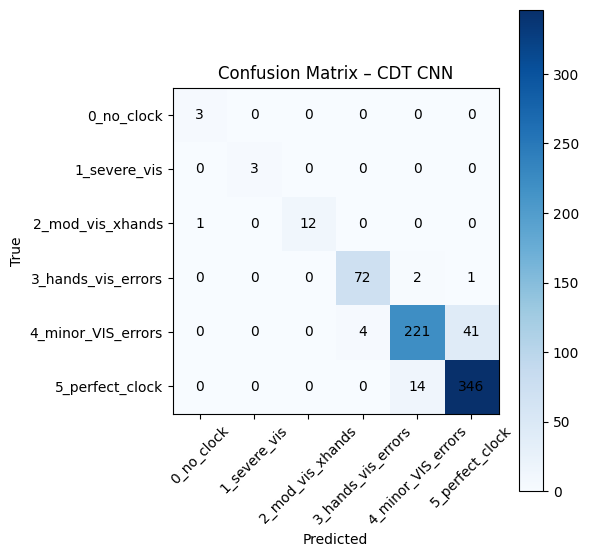

In [20]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix – CDT CNN")
plt.colorbar()

plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()



In [21]:
torch.save(model.state_dict(), "cdt_cnn_model.pth")
print("Model saved as cdt_cnn_model.pth")


Model saved as cdt_cnn_model.pth
